# KBO 롯데 자이언츠 What-if 프로젝트 — 탐색적 데이터 분석 (EDA)

**분석 순서**
1. 경기 단위 개요 (`games.csv`) — 데이터 범위·시즌 구조 파악
2. 타석 이벤트 분포 (`plate_appearances.csv`) — 타석 결과·상황 패턴
3. 모델 피처·라벨 분석 (`model_master_pa_extended_eligible.csv`) — 피처 분포·상관관계·라벨 균형
4. WE/RE 상태 공간 (`we_table.csv`, `re_table.csv`) — 승리/득점 기대값 시각화

In [14]:
import warnings
warnings.filterwarnings('ignore')

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import matplotlib as mpl

sns.set_style('whitegrid')

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


DATA = Path('../kbo_pipeline/data/processed')
print('준비 완료')

준비 완료


---
## 1단계 — 경기 단위 개요 (`games.csv`)

In [15]:
# games_detail.csv에 winner_team_code 포함
games = pd.read_csv(DATA / 'games_detail.csv')
games['season'] = games['game_id'].astype(str).str[:4].astype(int)
print(f'경기 수: {len(games):,}   시즌: {sorted(games["season"].unique())}')
games.head(3)

경기 수: 8,907   시즌: [np.int64(2008), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,game_id,game_date,game_time,stadium,away_team_code,away_team_name,away_team_full_name,home_team_code,home_team_name,home_team_full_name,away_starting_pitcher_pcode,home_starting_pitcher_pcode,away_score,home_score,winner_team_code,status_code,cancel_flag,season
0,20080601HTOB0,20080601,17:00,잠실,HT,KIA,KIA 타이거즈,OB,두산,두산 베어스,78627.0,75230.0,6.0,2.0,HT,4,N,2008
1,20080601LGHH0,20080601,14:00,청주,LG,LG,LG 트윈스,HH,한화,한화 이글스,77199.0,97336.0,8.0,2.0,LG,4,N,2008
2,20080601LTWO0,20080601,17:00,목동,LT,롯데,롯데 자이언츠,WO,히어로즈,키움 히어로즈,70434.0,76350.0,8.0,3.0,LT,4,N,2008


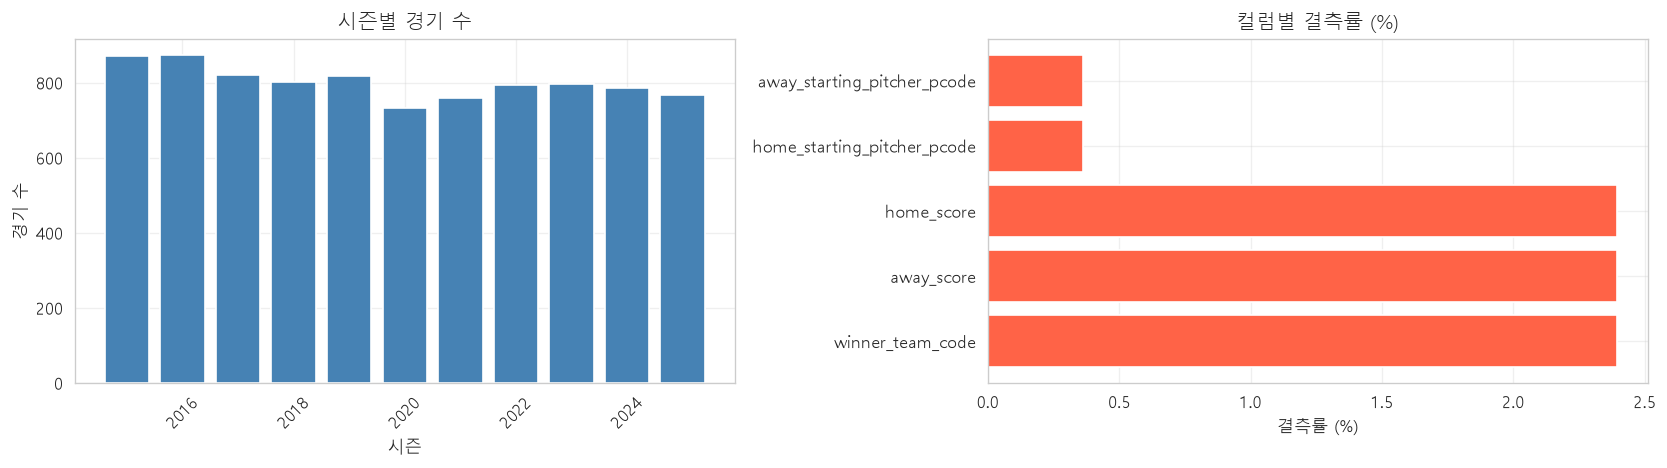

In [19]:
games = games[
    games["season"].between(2015, 2025)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 시즌별 경기 수
season_cnt = games['season'].value_counts().sort_index()
axes[0].bar(season_cnt.index, season_cnt.values, color='steelblue')
axes[0].set_title('시즌별 경기 수')
axes[0].set_xlabel('시즌')
axes[0].set_ylabel('경기 수')
axes[0].tick_params(axis='x', rotation=45)

# 컬럼별 결측률
missing = (games.isnull().sum() / len(games) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
if len(missing):
    axes[1].barh(missing.index, missing.values, color='tomato')
    axes[1].set_title('컬럼별 결측률 (%)')
    axes[1].set_xlabel('결측률 (%)')
else:
    axes[1].text(0.5, 0.5, '결측치 없음', ha='center', va='center', fontsize=14)
    axes[1].set_title('컬럼별 결측률 (%)')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [20]:
games["season"].value_counts().sort_index()

season
2015    871
2016    873
2017    820
2018    801
2019    818
2020    732
2021    760
2022    794
2023    796
2024    785
2025    768
Name: count, dtype: int64

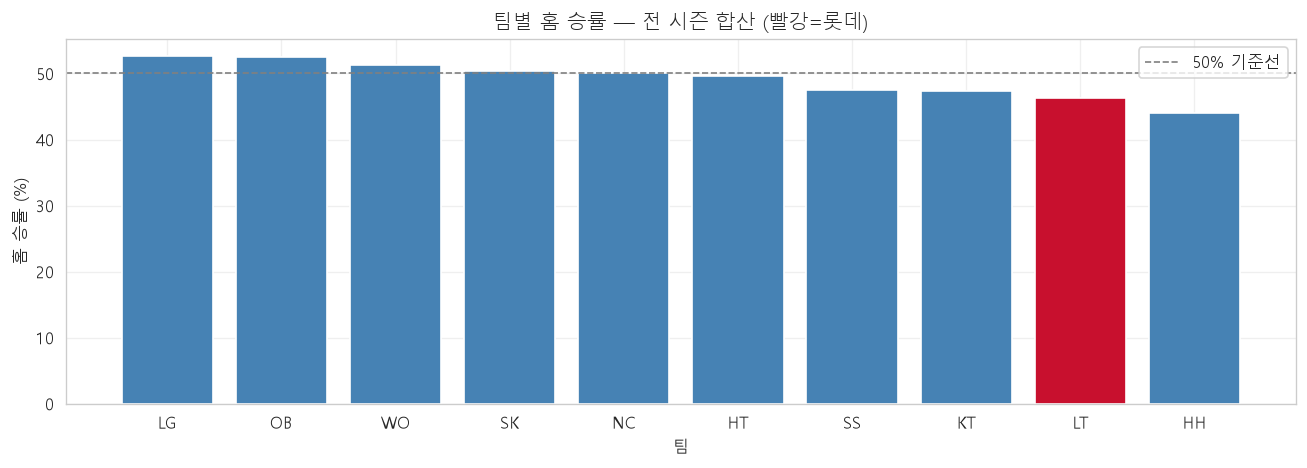

In [21]:
# 팀별 홈 승률
winner_col = 'winner_team_code'
home_col   = 'home_team_code'
away_col   = 'away_team_code'

total    = games[home_col].value_counts()
wins     = games[games[winner_col] == games[home_col]][home_col].value_counts()
win_rate = (wins / total * 100).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#C8102E' if t == 'LT' else 'steelblue' for t in win_rate.index]
ax.bar(win_rate.index, win_rate.values, color=colors)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% 기준선')
ax.set_title('팀별 홈 승률 — 전 시즌 합산 (빨강=롯데)')
ax.set_xlabel('팀')
ax.set_ylabel('홈 승률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

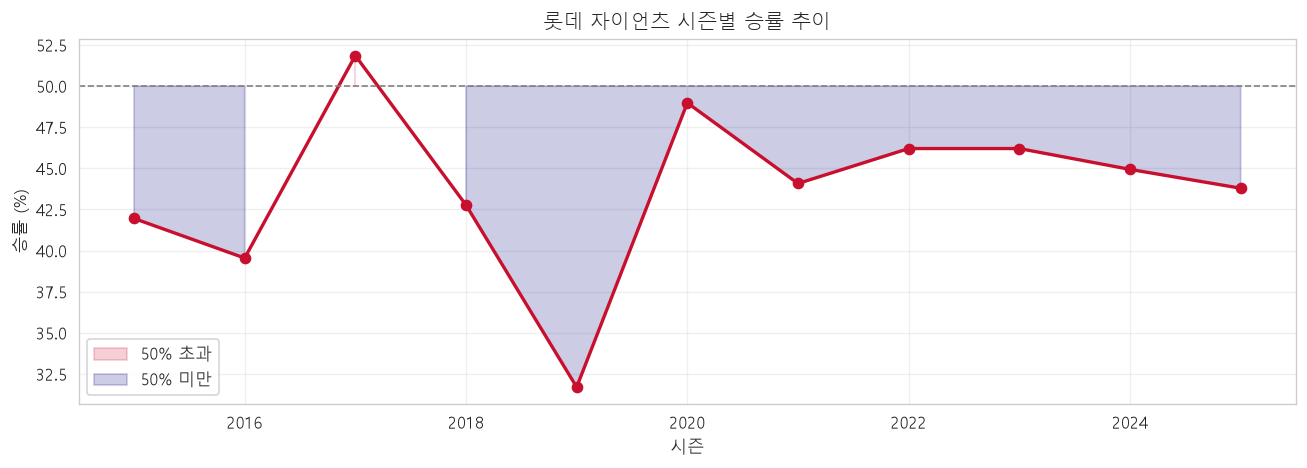

In [22]:
# 롯데 시즌별 승률 추이
lotte = games[(games[home_col] == 'LT') | (games[away_col] == 'LT')].copy()
lotte['lotte_win'] = (lotte[winner_col] == 'LT').astype(float)
lotte_rate = lotte.groupby('season')['lotte_win'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lotte_rate.index, lotte_rate.values, marker='o', color='#C8102E', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', linewidth=1)
ax.fill_between(lotte_rate.index, 50, lotte_rate.values,
                where=lotte_rate.values >= 50, alpha=0.2, color='#C8102E', label='50% 초과')
ax.fill_between(lotte_rate.index, 50, lotte_rate.values,
                where=lotte_rate.values < 50, alpha=0.2, color='navy', label='50% 미만')
ax.set_title('롯데 자이언츠 시즌별 승률 추이')
ax.set_xlabel('시즌')
ax.set_ylabel('승률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2단계 — 타석 이벤트 분포 (`plate_appearances.csv`)

In [26]:
pa = pd.read_csv(DATA / 'plate_appearances.csv')
pa['season'] = pa['game_id'].astype(str).str[:4].astype(int)

pa = pa[
    pa["season"].between(2015, 2025)
].copy()
print(f'타석 수: {len(pa):,}   컬럼: {len(pa.columns)}개')
pa[['game_id','inning','home_or_away','pa_result_type','outs_before',
    'base1_before','base2_before','base3_before','batting_team_code']].head(3)

타석 수: 661,136   컬럼: 57개


,game_id,inning,home_or_away,pa_result_type,outs_before,base1_before,base2_before,base3_before,batting_team_code
0,20150307HTNC0,1,0,single,0,0,0,0,HT
1,20150307HTNC0,1,0,single,0,1,0,0,HT
2,20150307HTNC0,1,0,out,1,0,0,0,HT


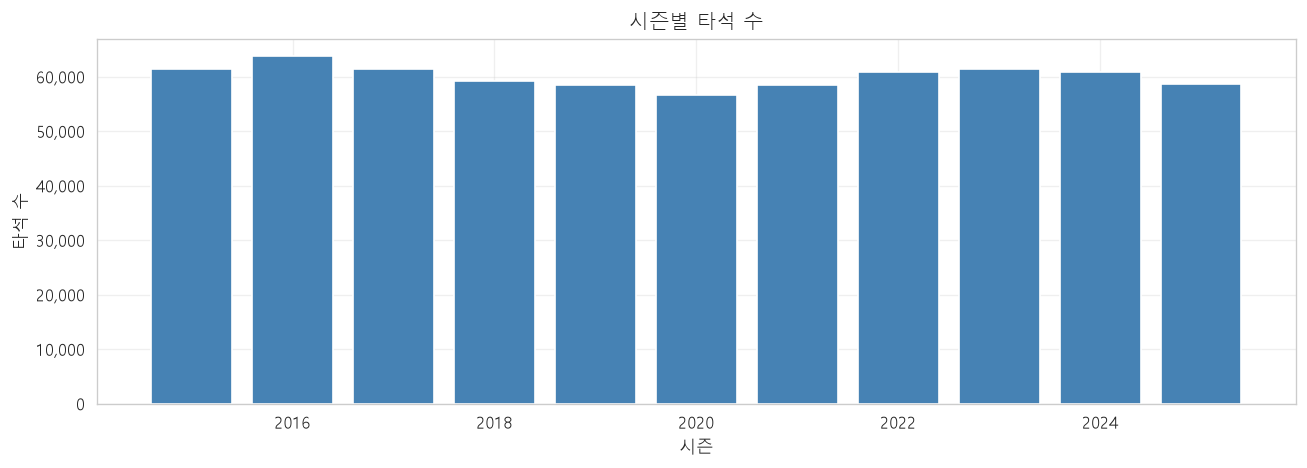

In [27]:
# 시즌별 타석 수
fig, ax = plt.subplots(figsize=(11, 4))
cnt = pa['season'].value_counts().sort_index()
ax.bar(cnt.index, cnt.values, color='steelblue')
ax.set_title('시즌별 타석 수')
ax.set_xlabel('시즌')
ax.set_ylabel('타석 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

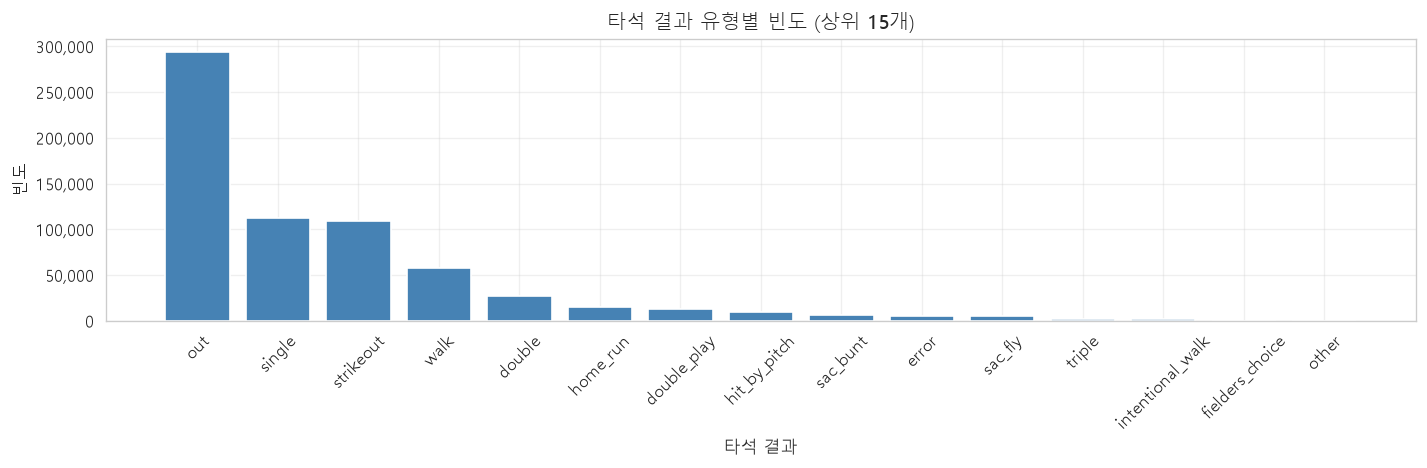

In [28]:
# 타석 결과 분포 (pa_result_type)
top_results = pa['pa_result_type'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(top_results.index.astype(str), top_results.values, color='steelblue')
ax.set_title('타석 결과 유형별 빈도 (상위 15개)')
ax.set_xlabel('타석 결과')
ax.set_ylabel('빈도')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

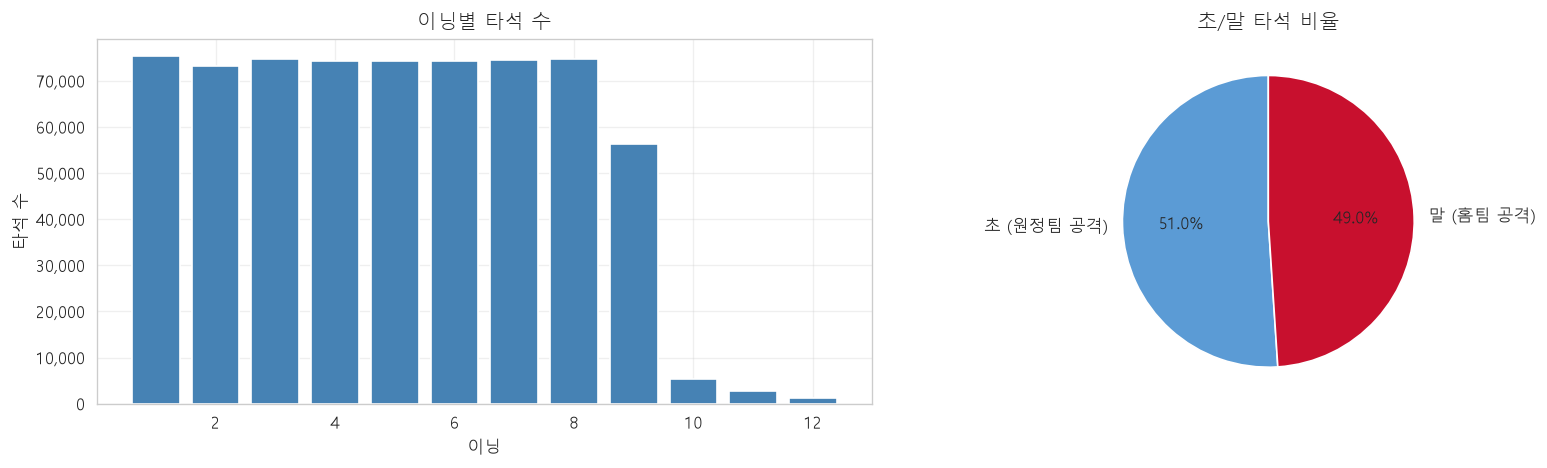

In [29]:
# 이닝별 타석 수 & 초/말 비율
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 이닝별
inning_cnt = pa['inning'].value_counts().sort_index()
axes[0].bar(inning_cnt.index, inning_cnt.values, color='steelblue')
axes[0].set_title('이닝별 타석 수')
axes[0].set_xlabel('이닝')
axes[0].set_ylabel('타석 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 초/말 비율
top_bot = pa['home_or_away'].map({0: '초 (원정팀 공격)', 1: '말 (홈팀 공격)'}).value_counts()
palette = ['#5B9BD5', '#C8102E'] if len(top_bot) == 2 else sns.color_palette('Set2', len(top_bot))
axes[1].pie(top_bot.values, labels=top_bot.index, autopct='%1.1f%%',
            colors=palette, startangle=90)
axes[1].set_title('초/말 타석 비율')

plt.tight_layout()
plt.show()

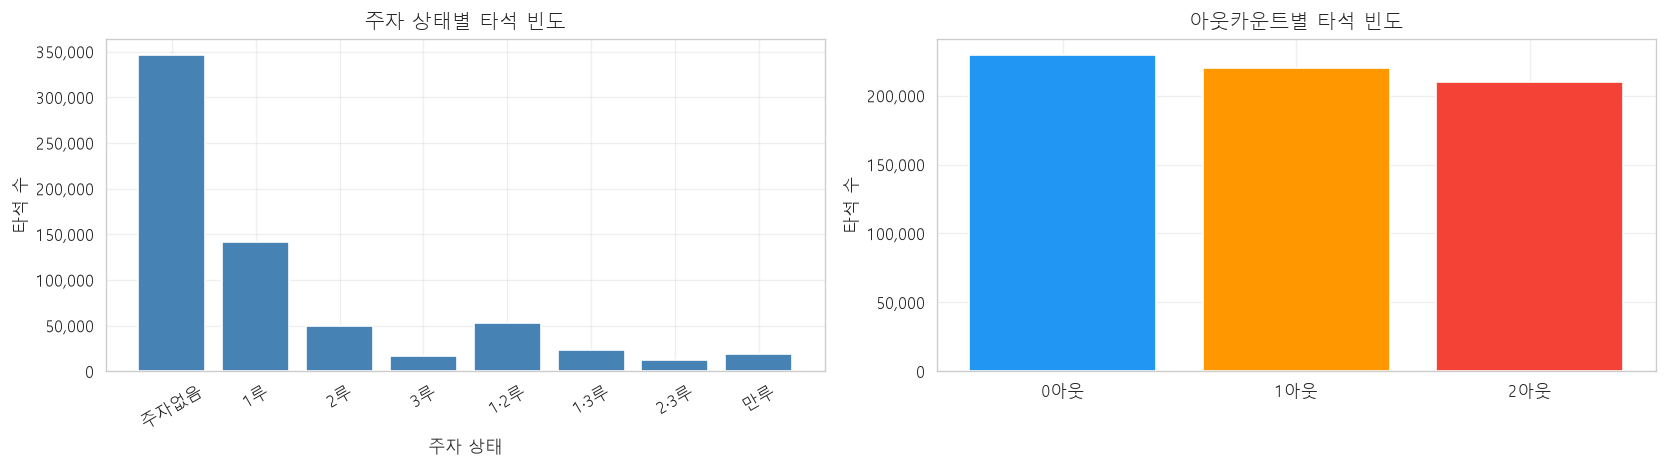

In [30]:
# 주자 상태별 빈도
pa['주자상태코드'] = (pa['base1_before'].fillna(0).clip(0,1).astype(int).astype(str)
                    + pa['base2_before'].fillna(0).clip(0,1).astype(int).astype(str)
                    + pa['base3_before'].fillna(0).clip(0,1).astype(int).astype(str))
label_map = {
    '000':'주자없음','100':'1루','010':'2루','001':'3루',
    '110':'1·2루','101':'1·3루','011':'2·3루','111':'만루'
}
pa['주자상태'] = pa['주자상태코드'].map(label_map).fillna(pa['주자상태코드'])

order = ['주자없음','1루','2루','3루','1·2루','1·3루','2·3루','만루']
state_cnt = pa['주자상태'].value_counts().reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(state_cnt.index, state_cnt.values, color='steelblue')
axes[0].set_title('주자 상태별 타석 빈도')
axes[0].set_xlabel('주자 상태')
axes[0].set_ylabel('타석 수')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 아웃카운트별
outs_cnt = pa['outs_before'].value_counts().sort_index()
outs_012 = outs_cnt.reindex([0,1,2], fill_value=0)
axes[1].bar(['0아웃','1아웃','2아웃'], outs_012.values,
            color=['#2196F3','#FF9800','#F44336'])
axes[1].set_title('아웃카운트별 타석 빈도')
axes[1].set_ylabel('타석 수')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

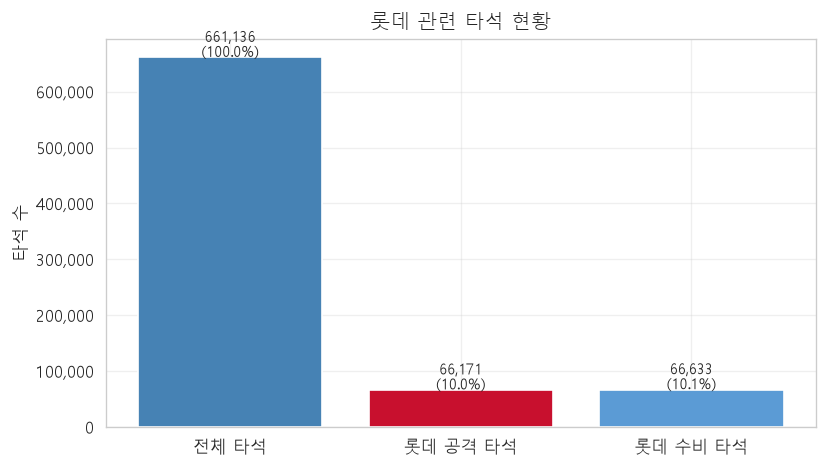

In [31]:
# 롯데 관련 타석 비율
lotte_bat  = pa['is_lotte_batting'].sum()
lotte_fld  = pa['is_lotte_fielding'].sum()
total_pa   = len(pa)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['전체 타석', '롯데 공격 타석', '롯데 수비 타석'],
       [total_pa, lotte_bat, lotte_fld],
       color=['steelblue','#C8102E','#5B9BD5'])
ax.set_title('롯데 관련 타석 현황')
ax.set_ylabel('타석 수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate([total_pa, lotte_bat, lotte_fld]):
    ax.text(i, v + 1000, f'{v:,}\n({v/total_pa*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 3단계 — 모델 피처·라벨 분석 (`model_master_pa_extended_eligible.csv`)

> 파일이 크므로 핵심 컬럼만 선택 로드합니다.

In [ ]:
LOAD_COLS = [
    'game_id',
    'inning', 'home_or_away', 'outs_before',
    'base1_before', 'base2_before', 'base3_before',
    'batting_score_diff_before',
    'state_we', 'state_re',
    'late_clutch', 'scoring_position_before',
    'is_top_bool', 'is_home_batting',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before',
    'pitcher_pre_k9_before',  'pitcher_pre_bb9_before',
    'pitcher_pre_ip_before',  'pitcher_pre_games_before',
    'batter_pre_games_before','batter_pre_cum_ab',
    'batter_pre_avg_before',  'batter_pre_slg_before',
    'batter_pre_ops_before',
    'batting_team_win_label',
]

df = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=lambda c: c in LOAD_COLS,
    dtype='float32',
    low_memory=False
)
# game_id는 문자열이므로 별도 로드
df['game_id'] = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=['game_id'], dtype=str
)['game_id']
df['season'] = df['game_id'].astype(str).str[:4].astype(int)

df = df[
    df["season"].between(2015, 2025)
].copy()

print(f'로드: {len(df):,}행 × {len(df.columns)}열  메모리: {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
df.describe().T[["count","mean","std","min","max"]].round(3)

In [33]:
LOAD_COLS = [
    'game_id',
    'inning', 'home_or_away', 'outs_before',
    'base1_before', 'base2_before', 'base3_before',
    'batting_score_diff_before',
    'state_we', 'state_re',
    'late_clutch', 'scoring_position_before',
    'is_top_bool', 'is_home_batting',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before',
    'pitcher_pre_k9_before',  'pitcher_pre_bb9_before',
    'pitcher_pre_ip_before',  'pitcher_pre_games_before',
    'batter_pre_games_before','batter_pre_cum_ab',
    'batter_pre_avg_before',  'batter_pre_slg_before',
    'batter_pre_ops_before',
    'batting_team_win_label',
]

BOOL_COLS = [
    "late_clutch",
    "scoring_position_before",
    "is_top_bool",
    "is_home_batting",
]

ID_COLS = ["game_id"]

NUM_COLS = [
    c for c in LOAD_COLS
    if c not in ID_COLS + BOOL_COLS
]

df = pd.read_csv(
    DATA / 'model_master_pa_extended_eligible.csv',
    usecols=lambda c: c in LOAD_COLS,
    dtype={"game_id": "string"},
    low_memory=False
)
# 시즌 생성
df["season"] = pd.to_numeric(
    df["game_id"].astype(str).str[:4],
    errors="coerce"
)

# 2015~2025만 필터링
df = df[df["season"].between(2015, 2025)].copy()
df["season"] = df["season"].astype("int16")

# 숫자 컬럼만 float32로 변환
for col in NUM_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

# bool 컬럼 정리
for col in BOOL_COLS:
    if col in df.columns:
        df[col] = (
            df[col]
            .map({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "true": 1,
                "false": 0,
                "1": 1,
                "0": 0,
                1: 1,
                0: 0,
            })
            .astype("float32")
        )

print(
    f"로드: {len(df):,}행 × {len(df.columns)}열  "
    f"메모리: {df.memory_usage(deep=True).sum()/1e6:.0f} MB"
)

df.describe().T[["count", "mean", "std", "min", "max"]].round(3)

로드: 687,954행 × 27열  메모리: 115 MB


,count,mean,std,min,max
inning,687954.0,4.973,2.598,1.000,12.000
home_or_away,687954.0,0.489,0.500,0.000,1.000
outs_before,687954.0,0.969,0.816,0.000,2.000
base1_before,687954.0,0.356,0.479,0.000,1.000
base2_before,687954.0,0.200,0.400,0.000,1.000
base3_before,687954.0,0.107,0.309,0.000,1.000
scoring_position_before,687954.0,0.259,0.438,0.000,1.000
late_clutch,687954.0,0.153,0.360,0.000,1.000
is_top_bool,687954.0,0.511,0.500,0.000,1.000
is_home_batting,687954.0,0.489,0.500,0.000,1.000


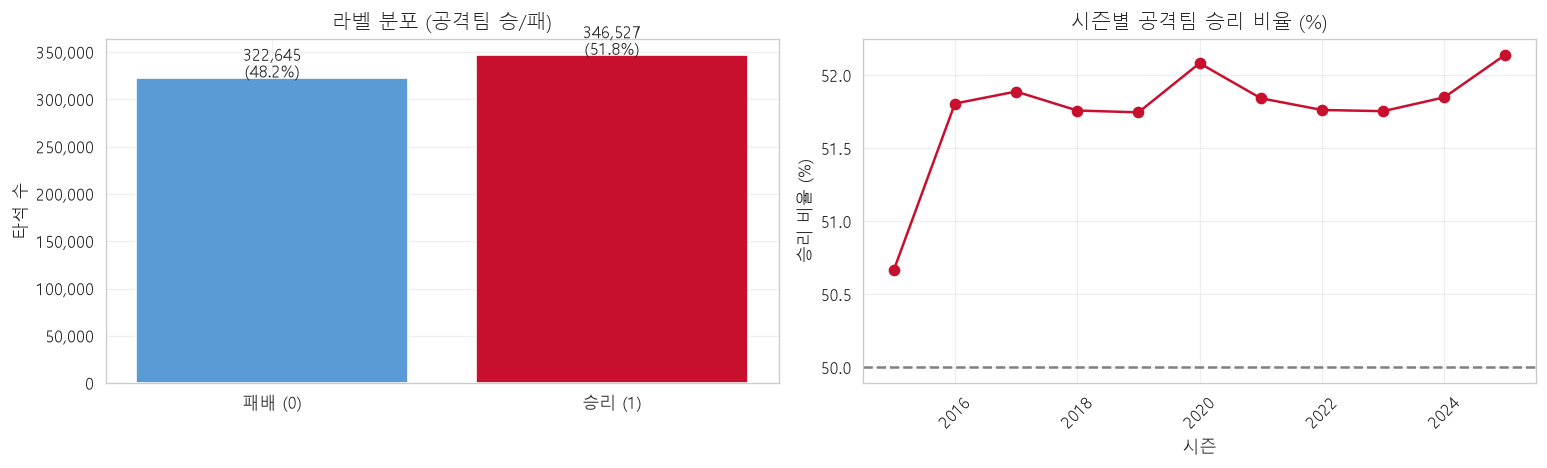

In [34]:
# 라벨 분포 (클래스 균형 확인)
label_valid = df[df['batting_team_win_label'].isin([0.0, 1.0])]['batting_team_win_label'].astype(int)
cnt = label_valid.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(['패배 (0)', '승리 (1)'], cnt.values, color=['#5B9BD5','#C8102E'])
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/cnt.sum()*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('라벨 분포 (공격팀 승/패)')
axes[0].set_ylabel('타석 수')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

season_win = (df[df['batting_team_win_label'].isin([0.0,1.0])]
              .groupby('season')['batting_team_win_label'].mean() * 100)
axes[1].plot(season_win.index, season_win.values, marker='o', color='#C8102E')
axes[1].axhline(50, color='gray', linestyle='--')
axes[1].set_title('시즌별 공격팀 승리 비율 (%)')
axes[1].set_xlabel('시즌')
axes[1].set_ylabel('승리 비율 (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

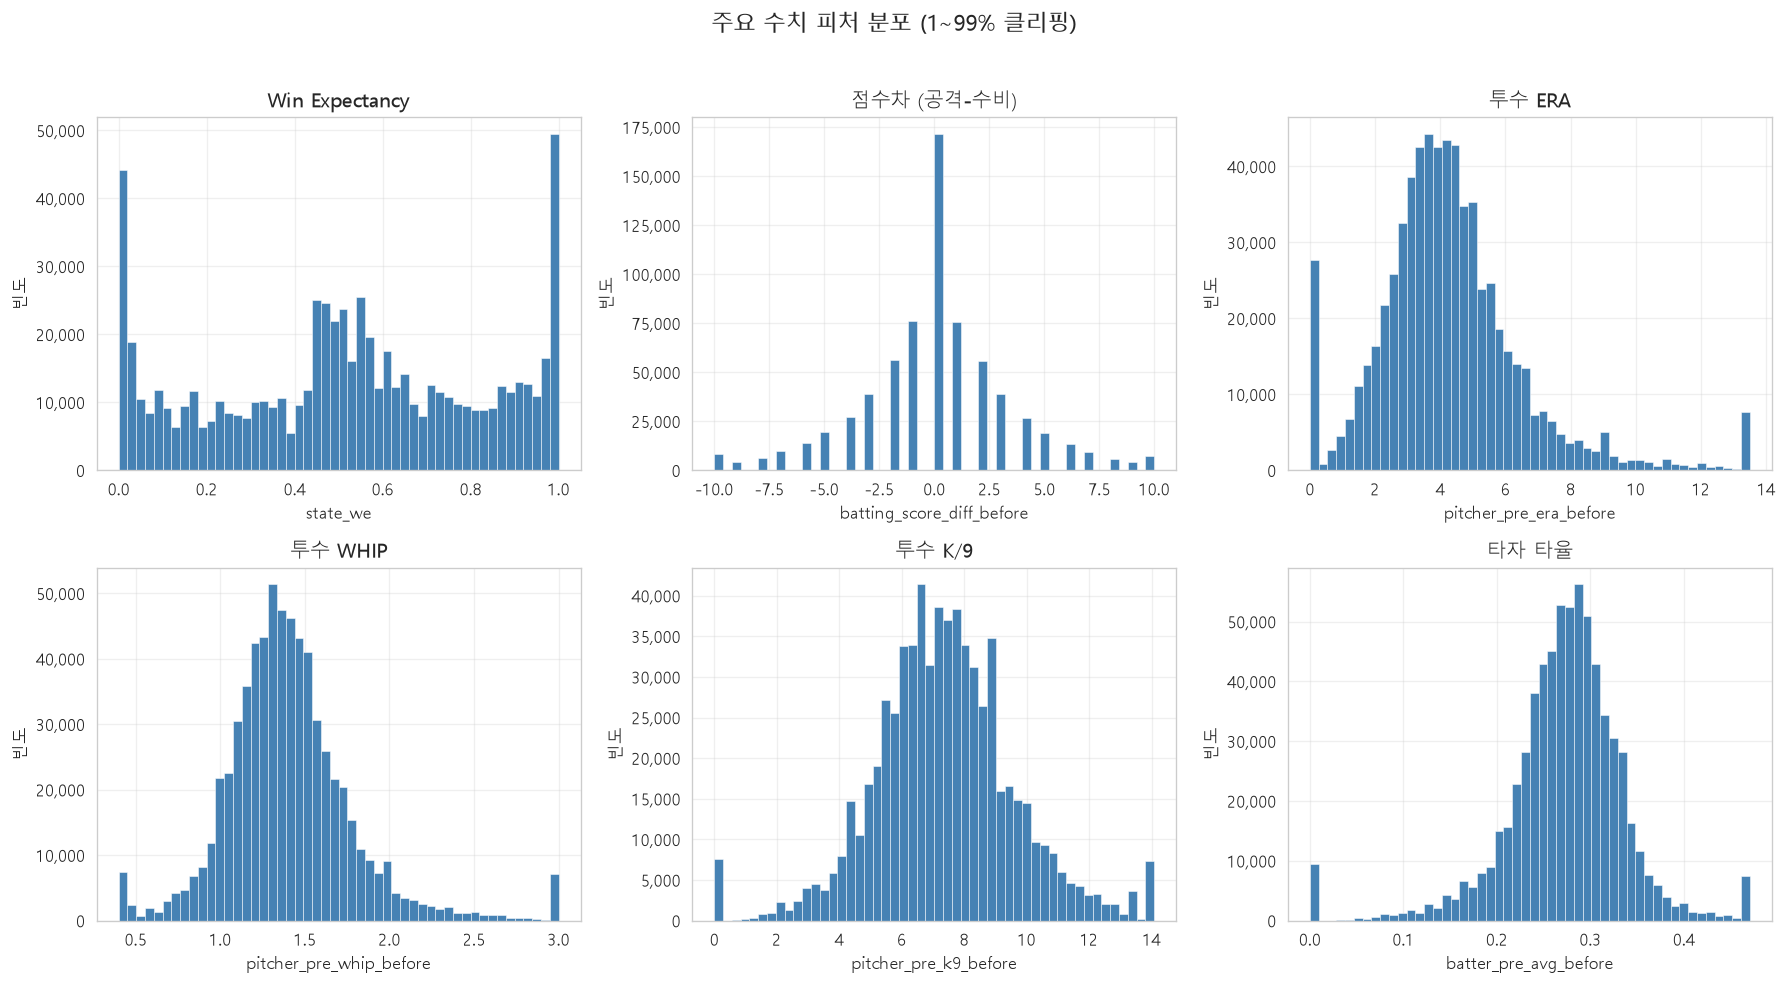

In [35]:
# 주요 수치 피처 분포 히스토그램
num_feats = [
    ('state_we',                  'Win Expectancy'),
    ('batting_score_diff_before', '점수차 (공격-수비)'),
    ('pitcher_pre_era_before',    '투수 ERA'),
    ('pitcher_pre_whip_before',   '투수 WHIP'),
    ('pitcher_pre_k9_before',     '투수 K/9'),
    ('batter_pre_avg_before',     '타자 타율'),
]
num_feats = [(c, lbl) for c, lbl in num_feats if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, lbl) in zip(axes.flatten(), num_feats):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    ax.hist(data.clip(lo, hi), bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(lbl)
    ax.set_xlabel(col)
    ax.set_ylabel('빈도')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('주요 수치 피처 분포 (1~99% 클리핑)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

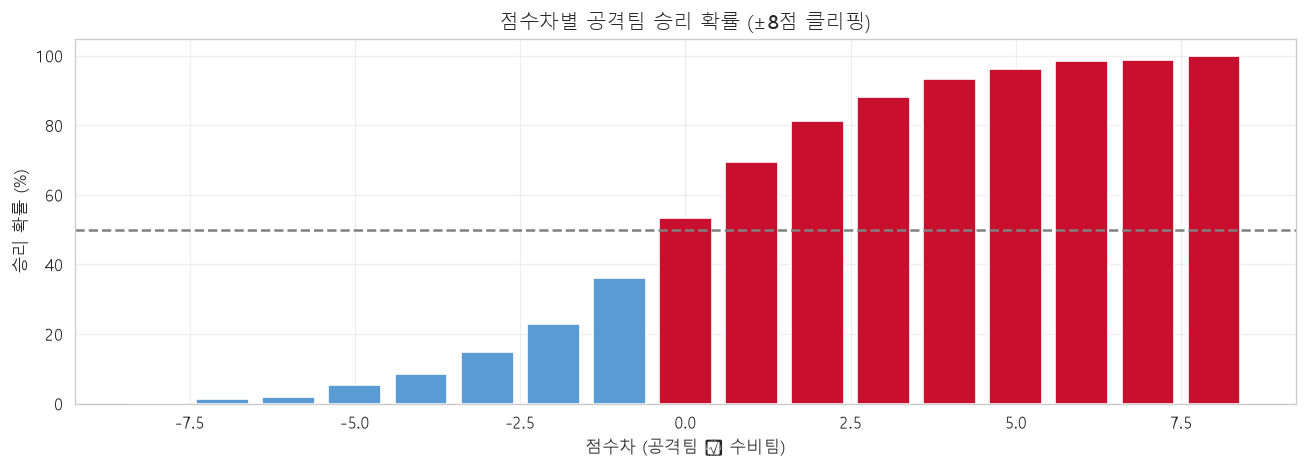

In [36]:
# 점수차별 공격팀 승리 확률
diff_win = (
    df[df['batting_team_win_label'].isin([0.0, 1.0])]
    .assign(diff_clip=df['batting_score_diff_before'].clip(-8, 8).astype(int))
    .groupby('diff_clip')['batting_team_win_label']
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#C8102E' if v >= 50 else '#5B9BD5' for v in diff_win.values]
ax.bar(diff_win.index, diff_win.values, color=colors)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('점수차별 공격팀 승리 확률 (±8점 클리핑)')
ax.set_xlabel('점수차 (공격팀 − 수비팀)')
ax.set_ylabel('승리 확률 (%)')
plt.tight_layout()
plt.show()

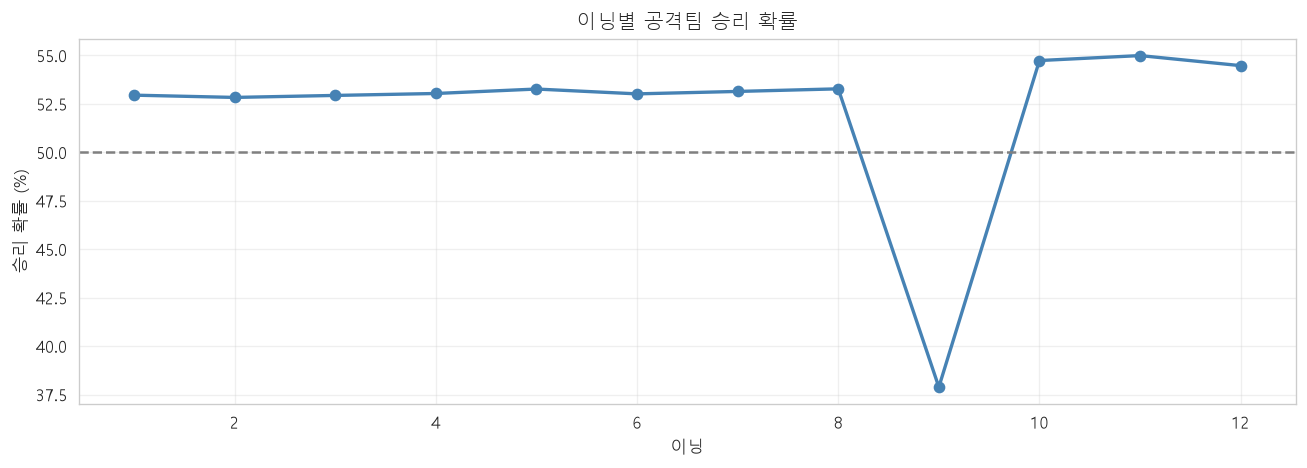

In [37]:
# 이닝별 공격팀 승리 확률
inn_win = (
    df[df['batting_team_win_label'].isin([0.0, 1.0])]
    .groupby('inning')['batting_team_win_label']
    .agg(['mean', 'count'])
)
inn_win = inn_win[inn_win['count'] >= 100]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(inn_win.index, inn_win['mean'] * 100, marker='o', color='steelblue', linewidth=2)
ax.axhline(50, color='gray', linestyle='--')
ax.set_title('이닝별 공격팀 승리 확률')
ax.set_xlabel('이닝')
ax.set_ylabel('승리 확률 (%)')
plt.tight_layout()
plt.show()

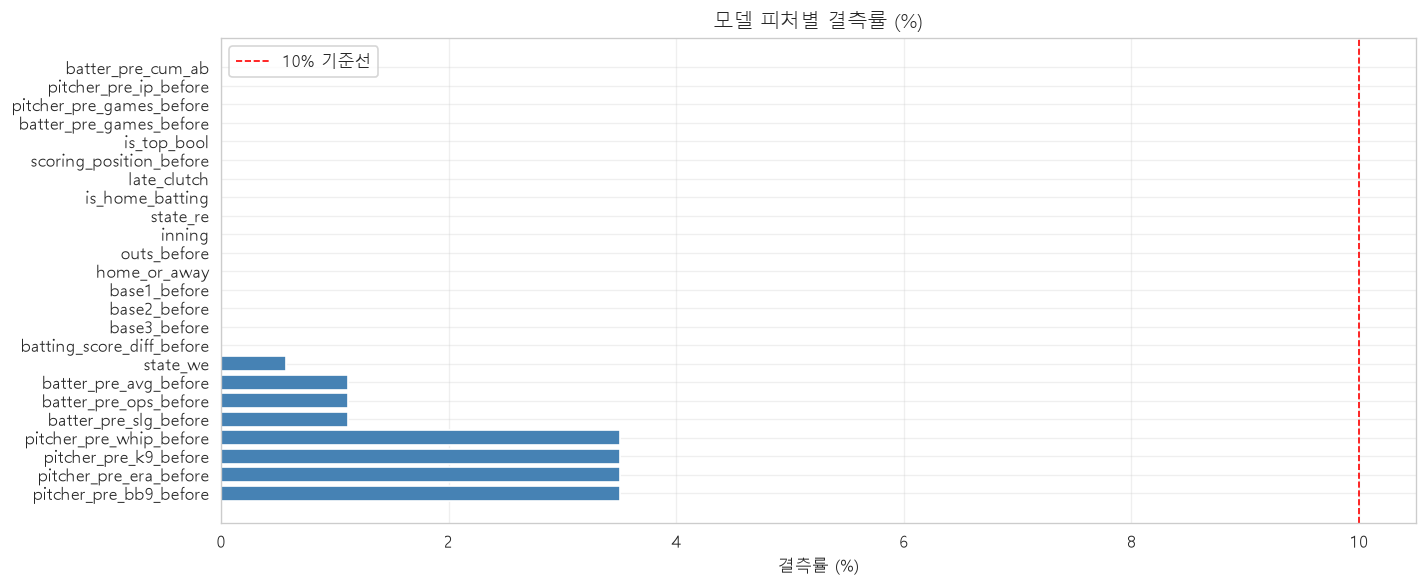

In [38]:
# 피처 결측률
feat_cols = [c for c in LOAD_COLS if c in df.columns
             and c not in ['game_id', 'season', 'batting_team_win_label']]
missing_rate = df[feat_cols].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['tomato' if v > 10 else 'steelblue' for v in missing_rate.values]
ax.barh(missing_rate.index, missing_rate.values, color=bar_colors)
ax.axvline(10, color='red', linestyle='--', linewidth=1, label='10% 기준선')
ax.set_title('모델 피처별 결측률 (%)')
ax.set_xlabel('결측률 (%)')
ax.legend()
plt.tight_layout()
plt.show()

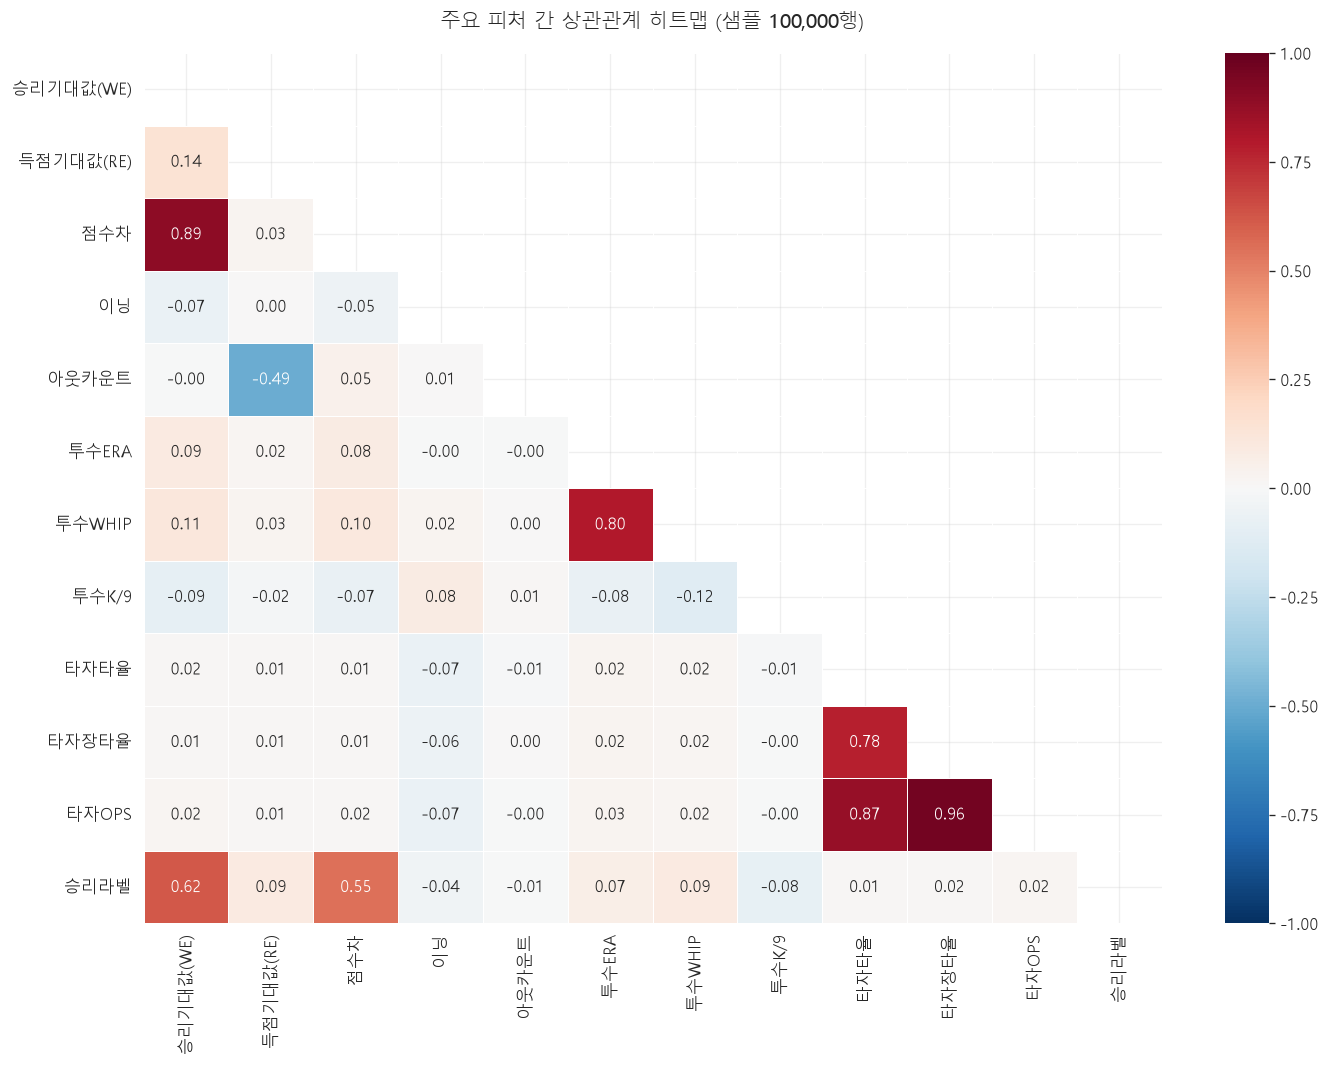

In [39]:
# 메모리 절약을 위해 10만 행 샘플로 상관관계 계산
corr_cols = [
    'state_we', 'state_re', 'batting_score_diff_before', 'inning', 'outs_before',
    'pitcher_pre_era_before', 'pitcher_pre_whip_before', 'pitcher_pre_k9_before',
    'batter_pre_avg_before', 'batter_pre_slg_before', 'batter_pre_ops_before',
    'batting_team_win_label',
]
corr_cols = [c for c in corr_cols if c in df.columns]
sample_df = df[corr_cols].dropna().sample(n=min(100_000, len(df)), random_state=42)
corr = sample_df.corr()

kr_labels = {
    'state_we': '승리기대값(WE)', 'state_re': '득점기대값(RE)',
    'batting_score_diff_before': '점수차',
    'inning': '이닝', 'outs_before': '아웃카운트',
    'pitcher_pre_era_before': '투수ERA', 'pitcher_pre_whip_before': '투수WHIP',
    'pitcher_pre_k9_before': '투수K/9',
    'batter_pre_avg_before': '타자타율', 'batter_pre_slg_before': '타자장타율',
    'batter_pre_ops_before': '타자OPS', 'batting_team_win_label': '승리라벨',
}
corr.index   = [kr_labels.get(c, c) for c in corr.index]
corr.columns = [kr_labels.get(c, c) for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f'주요 피처 간 상관관계 히트맵 (샘플 {len(sample_df):,}행)', pad=15)
plt.tight_layout()
plt.show()

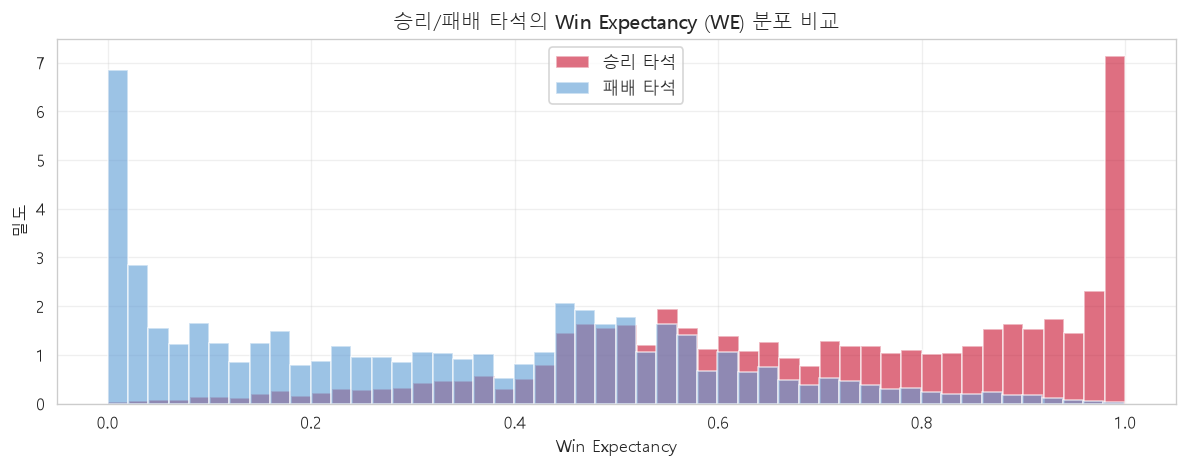

In [40]:
# 승/패별 Win Expectancy 분포 비교
win_we  = df[df['batting_team_win_label'] == 1.0]['state_we'].dropna()
lose_we = df[df['batting_team_win_label'] == 0.0]['state_we'].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(win_we,  bins=50, alpha=0.6, color='#C8102E', label='승리 타석', density=True)
ax.hist(lose_we, bins=50, alpha=0.6, color='#5B9BD5', label='패배 타석', density=True)
ax.set_title('승리/패배 타석의 Win Expectancy (WE) 분포 비교')
ax.set_xlabel('Win Expectancy')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.show()

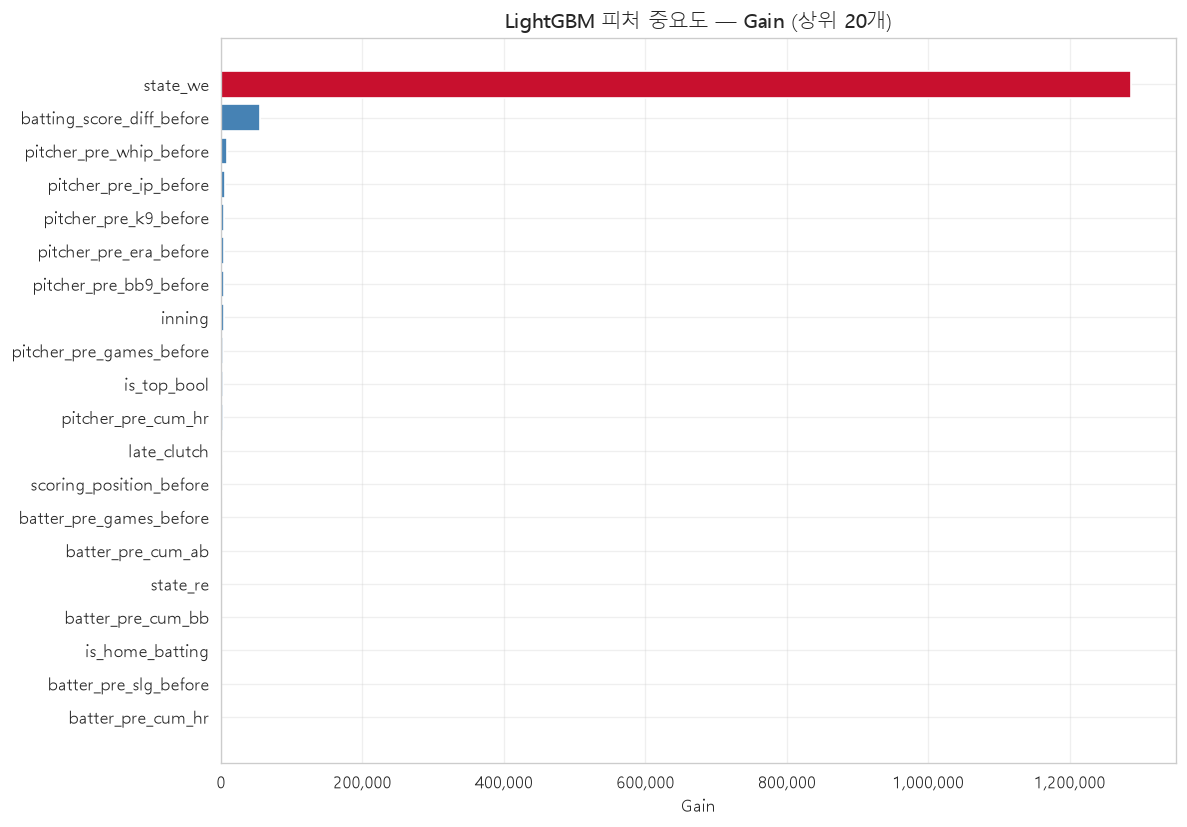

In [44]:
# 피처 중요도 (학습 결과)
try:
    fi = pd.read_csv('../kbo_pipeline/models/feature_importance.csv')
    fi_top = fi.sort_values('importance_gain', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    bar_colors = ['#C8102E'] + ['steelblue'] * (len(fi_top) - 1)
    ax.barh(fi_top['feature'][::-1], fi_top['importance_gain'][::-1],
            color=bar_colors[::-1])
    ax.set_title('LightGBM 피처 중요도 — Gain (상위 20개)')
    ax.set_xlabel('Gain')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('feature_importance.csv 없음 — run_train_models.py 먼저 실행 필요')

---
## 4단계 — WE/RE 상태 공간 시각화 (`we_table.csv`, `re_table.csv`)

In [45]:
we = pd.read_csv(DATA / 'we_table.csv')
re = pd.read_csv(DATA / 're_table.csv')
print('WE 테이블:', we.shape, '  컬럼:', we.columns.tolist())
print('RE 테이블:', re.shape, '  컬럼:', re.columns.tolist())
we.head(5)

WE 테이블: (5273, 3)   컬럼: ['state_key', 'we', 'we_n']
RE 테이블: (24, 4)   컬럼: ['outs_before', 'base_state_before', 're', 're_n']


,state_key,we,we_n
0,1_bot_d-1_o0_b000,0.473026,1279
1,1_bot_d-1_o0_b001,0.472222,18
2,1_bot_d-1_o0_b010,0.606557,61
3,1_bot_d-1_o0_b011,NaN,8
4,1_bot_d-1_o0_b100,0.544192,396


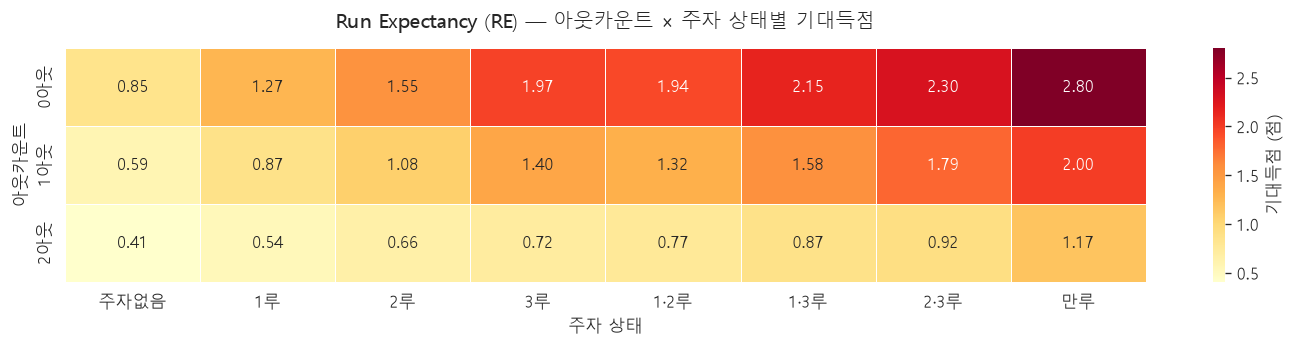

In [46]:
# RE 히트맵 (3아웃 × 8주자)
re_plot = re.copy()
re_plot['base_state_before'] = re_plot['base_state_before'].astype(str).str.zfill(3)
base_label = {
    '000':'주자없음','100':'1루','010':'2루','001':'3루',
    '110':'1·2루','101':'1·3루','011':'2·3루','111':'만루'
}
re_plot['주자상태'] = re_plot['base_state_before'].map(base_label)
re_plot['아웃'] = re_plot['outs_before'].astype(str) + '아웃'

col_order = ['주자없음','1루','2루','3루','1·2루','1·3루','2·3루','만루']
pivot_re = re_plot.pivot(index='아웃', columns='주자상태', values='re')
pivot_re = pivot_re[[c for c in col_order if c in pivot_re.columns]]

fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(pivot_re, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '기대득점 (점)'})
ax.set_title('Run Expectancy (RE) — 아웃카운트 × 주자 상태별 기대득점', pad=12)
ax.set_xlabel('주자 상태')
ax.set_ylabel('아웃카운트')
plt.tight_layout()
plt.show()

In [47]:
# WE 키 파싱: {이닝}_{top/bot}_d{점수차}_o{아웃}_b{주자}
we_valid = we[we['we_n'] >= 10].copy()
parts = we_valid['state_key'].str.extract(
    r'^(?P<이닝>\d+)_(?P<초말>[^_]+)_d(?P<점수차>-?\d+)_o(?P<아웃>\d+)_b(?P<주자>\d+)$'
)
we_valid = pd.concat([we_valid, parts], axis=1)
we_valid['이닝']  = we_valid['이닝'].astype(int)
we_valid['점수차'] = we_valid['점수차'].astype(int)
we_valid['아웃']  = we_valid['아웃'].astype(int)
we_valid['초말']  = we_valid['초말'].map({'top':'초(원정)','bot':'말(홈)'})
print(f'파싱 성공: {we_valid["이닝"].notna().sum():,}개')
we_valid.head(3)

파싱 성공: 4,495개


,state_key,we,we_n,이닝,초말,점수차,아웃,주자
0,1_bot_d-1_o0_b000,0.473026,1279,1,말(홈),-1,0,000
1,1_bot_d-1_o0_b001,0.472222,18,1,말(홈),-1,0,001
2,1_bot_d-1_o0_b010,0.606557,61,1,말(홈),-1,0,010


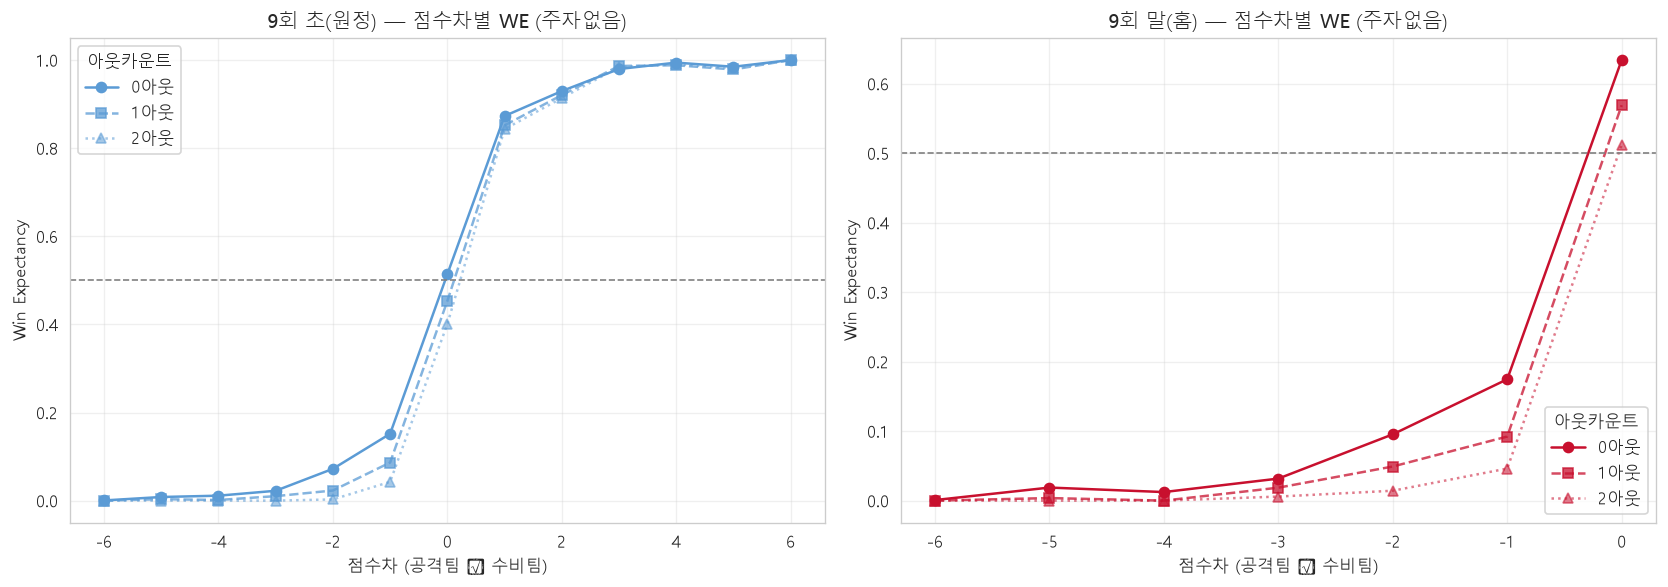

In [48]:
# 9회 주자없음 기준 — 점수차·아웃별 WE
subset = we_valid[(we_valid['이닝'] == 9) & (we_valid['주자'] == '000')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (side, color), ax in zip([('초(원정)','#5B9BD5'), ('말(홈)','#C8102E')], axes):
    s = subset[subset['초말'] == side].sort_values('점수차')
    for outs_val, (style, alpha) in enumerate([('o-', 1.0), ('s--', 0.75), ('^:', 0.55)]):
        ss = s[s['아웃'] == outs_val]
        if len(ss):
            ax.plot(ss['점수차'], ss['we'], style, color=color, alpha=alpha,
                    label=f'{outs_val}아웃')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'9회 {side} — 점수차별 WE (주자없음)')
    ax.set_xlabel('점수차 (공격팀 − 수비팀)')
    ax.set_ylabel('Win Expectancy')
    ax.legend(title='아웃카운트')

plt.tight_layout()
plt.show()

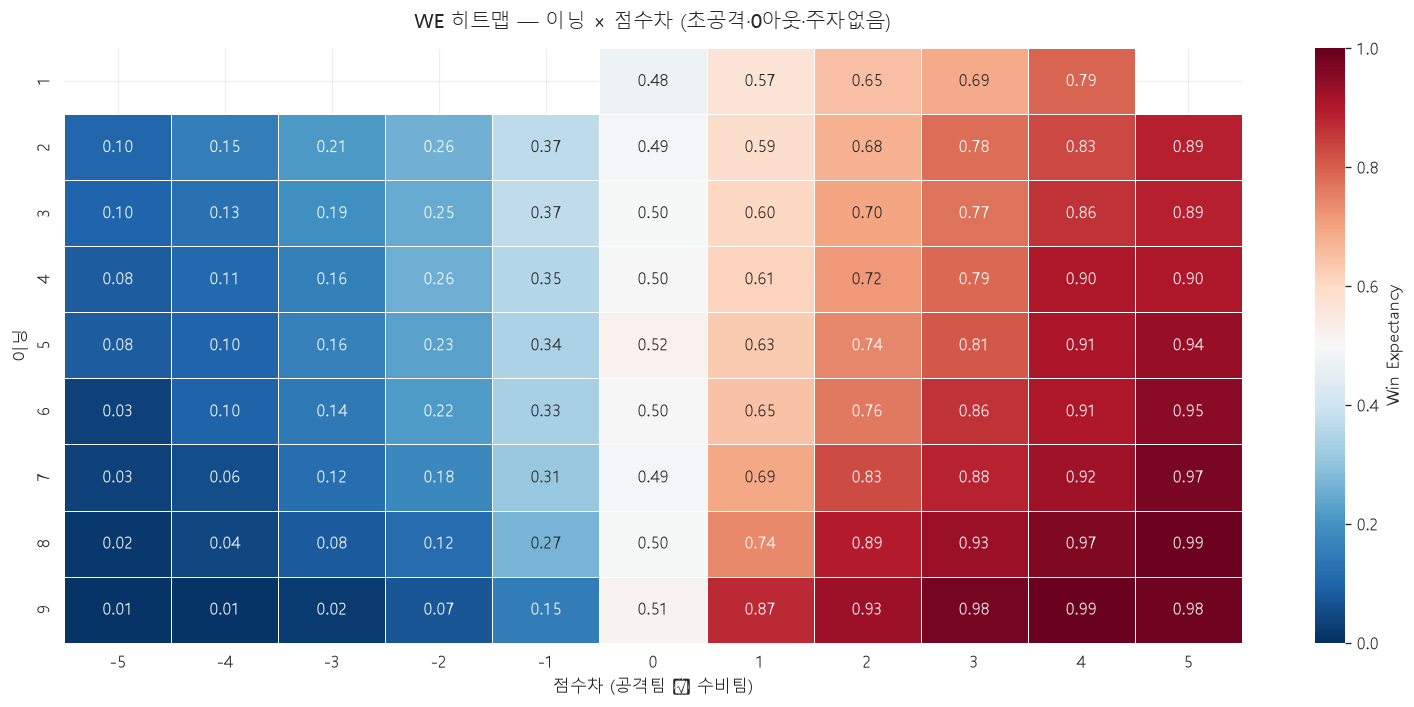

In [49]:
# WE 히트맵 — 이닝 × 점수차 (초공격, 0아웃, 주자없음)
pivot_we = (
    we_valid[
        (we_valid['초말'] == '초(원정)') &
        (we_valid['아웃'] == 0) &
        (we_valid['주자'] == '000')
    ]
    .pivot_table(index='이닝', columns='점수차', values='we')
)
# 점수차 ±5 범위만
cols_show = sorted([c for c in pivot_we.columns if -5 <= c <= 5])
pivot_we  = pivot_we[cols_show]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_we, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0.5, vmin=0, vmax=1, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Win Expectancy'})
ax.set_title('WE 히트맵 — 이닝 × 점수차 (초공격·0아웃·주자없음)', pad=12)
ax.set_xlabel('점수차 (공격팀 − 수비팀)')
ax.set_ylabel('이닝')
plt.tight_layout()
plt.show()

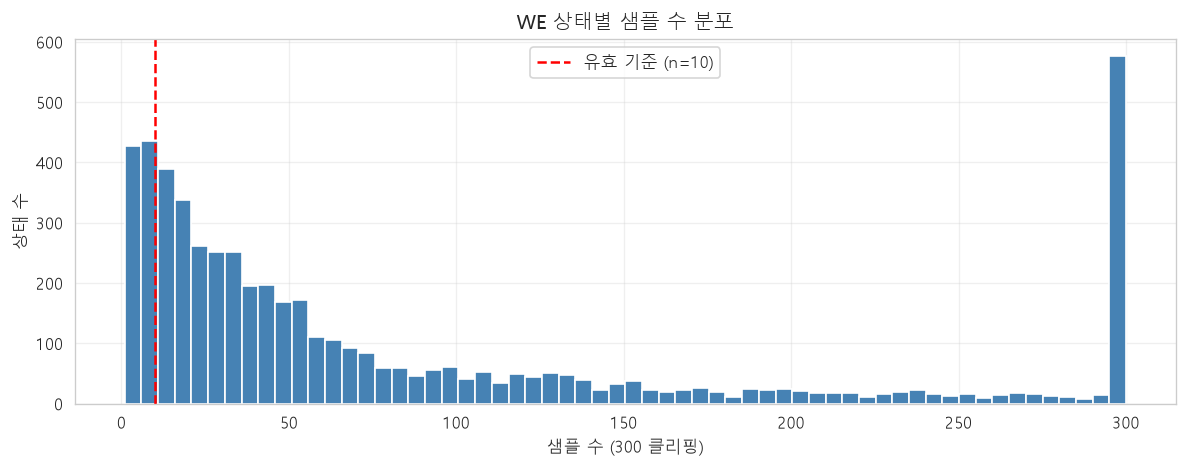

총 상태: 5,273  /  유효(n≥10): 4,495 (85.2%)


In [50]:
# WE 샘플 수 분포 (신뢰도)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(we['we_n'].clip(0, 300), bins=60, color='steelblue', edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='유효 기준 (n=10)')
ax.set_title('WE 상태별 샘플 수 분포')
ax.set_xlabel('샘플 수 (300 클리핑)')
ax.set_ylabel('상태 수')
ax.legend()
plt.tight_layout()
plt.show()
print(f'총 상태: {len(we):,}  /  유효(n≥10): {(we["we_n"]>=10).sum():,} ({(we["we_n"]>=10).mean()*100:.1f}%)')

---
## 요약

| 분석 항목 | 주요 인사이트 |
|-----------|---------------|
| 데이터 범위 | 2015~2025 시즌, 경기 9,372개, 타석 66만+ |
| 라벨 균형 | 공격팀 승리 ≈ 50% — 균형 잡힌 이진 분류 문제 |
| 핵심 피처 | state_we (gain 압도적 1위) — 이닝·점수차·아웃·주자 복합 사전 확률 |
| 투수 영향 | ERA/WHIP/K9 등 투수 스탯이 2~8위 — 투수 교체 의사결정에 중요 |
| WE 패턴 | 9회 동점 말 공격 WE ≈ 0.6+ (홈 어드밴티지 뚜렷) |
| RE 패턴 | 만루 0아웃이 기대득점 최대, 주자없음 2아웃이 최소 |